# `boundaries`: Country snapping

This notebook is for exploring how we're going to snap country boundaries from Natural Earth to our BKG data

max.koehler@swr.de

In [1]:
import geopandas as gp
import shapely as shp
from matplotlib import pyplot as plt
from tqdm import tqdm
tqdm.pandas()

In [ ]:
data = {}
data["ne"] = gp.read_file("zip://../tmp/raw/ne_50m_admin_0_countries.zip/ne_50m_admin_0_countries.shp")
for k in ["STA"]:
    data[k] = gp.read_file(f"zip://../tmp/raw/2025-01-01_vg250_01-01.utm32s.shape.ebenen.zip!vg250_01-01.utm32s.shape.ebenen/vg250_ebenen_0101/VG250_{k}.shp")

EPSG:25832


100%|██████████| 241/241 [00:00<00:00, 3224.12it/s]


EPSG:3857


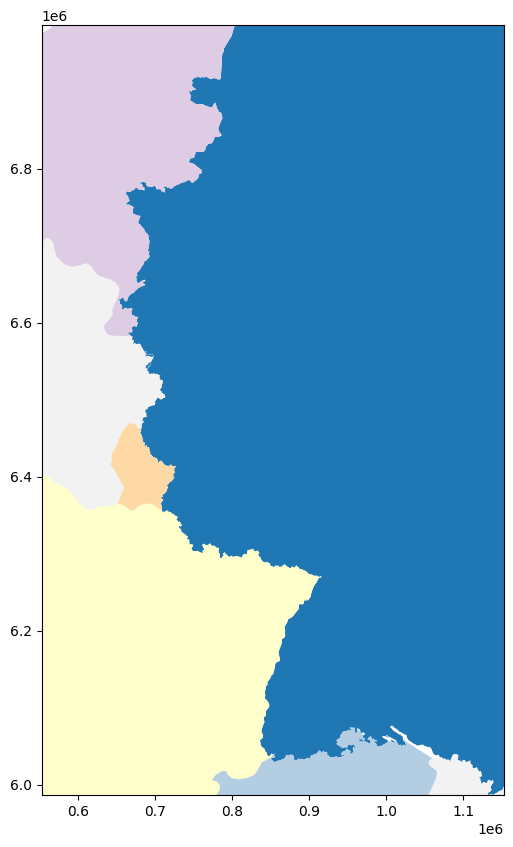

In [11]:
print(data["STA"].crs)
germany = (
    data["STA"].loc[data["STA"]["OBJID"] == "DEBKGVG200000CKM"].to_crs("EPSG:3857")
)
ne_countries = data["ne"].loc[data["ne"]["ADMIN"] != "Germany"].to_crs("EPSG:3857")
ne_countries["name"] = ne_countries["NAME_DE"]
ne_countries["admin_level"] = 2
ne_countries["kind"] = "Staat"

neighbours = (
    "Austria",
    "Belgium",
    "Czech Republic",
    "Denmark",
    "France",
    "Luxembourg",
    "Netherlands",
    "Poland",
    "Switzerland",
)

ne_countries["geometry"] = ne_countries.progress_apply(
    lambda x: (
        x["geometry"].buffer(5_000).difference(germany["geometry"][0])
        if x["ADMIN"] in neighbours
        else x["geometry"]
    ),
    axis=1,
)

fig, ax = plt.subplots(figsize=(8, 10))
bounds = germany.bounds.to_dict()
ax.set_xlim(bounds["minx"][0] - 1e5, bounds["minx"][0] + 5e5)
ax.set_ylim(bounds["miny"][0], bounds["miny"][0] + 1e6)

germany.plot(ax=ax)
ne_countries.plot(ax=ax, cmap="Pastel1")
print(ne_countries.crs)